# Exploratory Data Analysis - Preprocessed Pelvic MRI Dataset

Exploratory analysis and visualization of the preprocessed pelvic MRI slices used to
train the multi-model voting ensemble for endometriosis identification.

In [20]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

def _find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for _ in range(10):
        if (current / "configs" / "config.yaml").exists():
            return current
        current = current.parent

    raise SystemExit(
        "Could not locate configs/config.yaml. Run the notebook from "
        "anywhere inside the repository."
    )

REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "savefig.dpi": 150,
    "figure.figsize": (10, 6),
})

with open(REPO_ROOT / "configs" / "config.yaml", "r") as fh:
    config = yaml.safe_load(fh)

print("Config loaded.")
print("  raw dir       :", config["data"]["raw_dir"])
print("  processed dir :", config["data"]["processed_dir"])
print("  image size    :", config["preprocessing"]["image_size"])
print("  sequences     :", config["preprocessing"]["sequences"])
print("  seed          :", config["split"]["seed"])

Config loaded.
  raw dir       : data/raw
  processed dir : data/processed
  image size    : [224, 224]
  sequences     : ['T1', 'T1FS', 'T2', 'T2FS']
  seed          : 42


In [8]:
PROCESSED_DIR = REPO_ROOT / config["data"]["processed_dir"]
MANIFEST_PATH = PROCESSED_DIR / "manifest.csv"

if not MANIFEST_PATH.exists():
    raise SystemExit(
        "manifest.csv not found. Run `python src/preprocess.py` "
        "to generate the preprocessed dataset first."
    )
print("manifest.csv found.")

manifest.csv found.


In [9]:
df = pd.read_csv(MANIFEST_PATH)

print(f"Total slices     : {len(df):,}")
print(f"Unique patients  : {df['patient_id'].nunique()}")
print(f"Unique sequences : {sorted(df['sequence'].unique())}")
print()
df.head(10)

Total slices     : 22,178
Unique patients  : 121
Unique sequences : ['T1', 'T1FS', 'T2', 'T2FS']



,filename,patient_id,sequence,split,label
0,train\D2-054\T1_slice_0000.npy,D2-054,T1,train,1
1,train\D2-054\T1_slice_0001.npy,D2-054,T1,train,1
2,train\D2-054\T1_slice_0002.npy,D2-054,T1,train,1
3,train\D2-054\T1_slice_0003.npy,D2-054,T1,train,1
4,train\D2-054\T1_slice_0004.npy,D2-054,T1,train,1
5,train\D2-054\T1_slice_0005.npy,D2-054,T1,train,1
6,train\D2-054\T1_slice_0006.npy,D2-054,T1,train,1
7,train\D2-054\T1_slice_0007.npy,D2-054,T1,train,1
8,train\D2-054\T1_slice_0008.npy,D2-054,T1,train,1
9,train\D2-054\T1_slice_0009.npy,D2-054,T1,train,1


## 1. Dataset Overview

`test/` is currently empty — the local hospital (DICOM) dataset will populate it and
serve as the independent external validation set.

In [21]:
overview = (
    df.groupby("split")
    .agg(patients=("patient_id", "nunique"), slices=("filename", "count"))
    .reindex(["train", "validation", "test"])
)
overview["slices_per_patient"] = (overview["slices"] / overview["patients"]).round(1)
overview

print(f"\nOverall slices per patient (mean): {len(df) / df['patient_id'].nunique():.1f}")
overview


Overall slices per patient (mean): 183.3


,patients,slices,slices_per_patient
split,,,
train,96.0,17201.0,179.2
validation,25.0,4977.0,199.1
test,NaN,NaN,NaN


## 2. Class Distribution

Labels: `1 = endometriosis`, `0 = healthy`. Currently all slices are positive because the
healthy pelvis dataset (negative class) has not been acquired yet — preprocessing already
runs end-to-end once it lands.

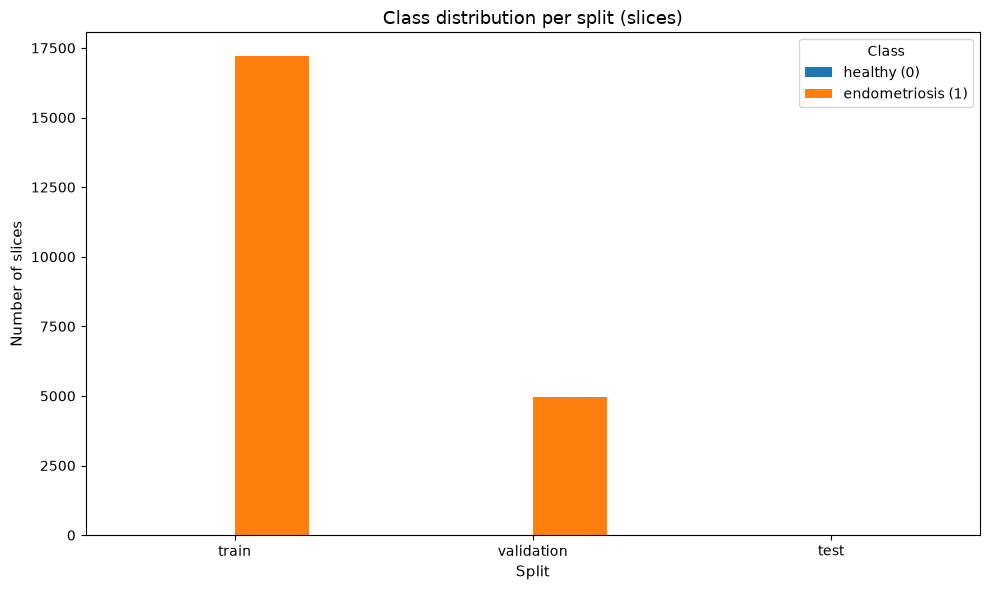

,healthy (0),endometriosis (1)
split,,
train,0.0,17201.0
validation,0.0,4977.0
test,NaN,NaN


In [12]:
label_counts = (
    df.groupby(["split", "label"]).size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1], fill_value=0)  # ← ensures both columns
    .reindex(["train", "validation", "test"])
)
label_counts.columns = ["healthy (0)", "endometriosis (1)"]

label_counts.plot(kind="bar")
plt.title("Class distribution per split (slices)")
plt.xlabel("Split")
plt.ylabel("Number of slices")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

label_counts

## 3. Sequence Coverage

Each patient may have any subset of the T1, T1FS, T2, T2FS sequences (data is incomplete
and inconsistent across patients), so coverage is reported both per sequence and per source
dataset (D1 = Memorial Hermann, D2 = Texas Children's).

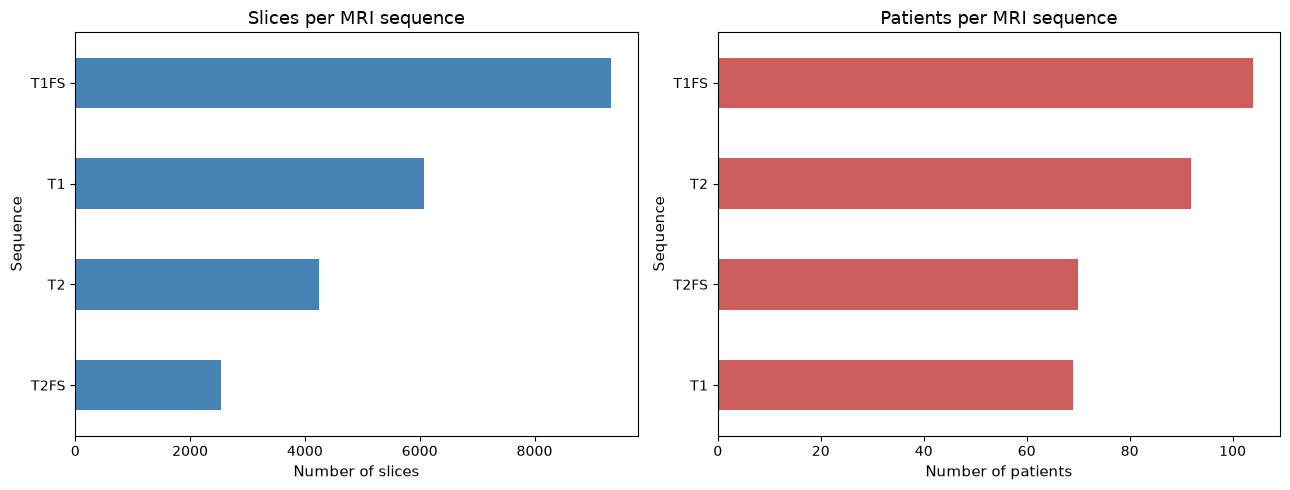

Slices per sequence per dataset:
sequence    T1  T1FS    T2  T2FS
dataset                         
D1           0  3846  1943     0
D2        6074  5482  2299  2534


In [13]:
df["dataset"] = df["patient_id"].str.extract(r"(D[12])")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df["sequence"].value_counts().sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Slices per MRI sequence")
axes[0].set_xlabel("Number of slices")
axes[0].set_ylabel("Sequence")

df.groupby("sequence")["patient_id"].nunique().sort_values().plot(
    kind="barh", ax=axes[1], color="indianred"
)
axes[1].set_title("Patients per MRI sequence")
axes[1].set_xlabel("Number of patients")
axes[1].set_ylabel("Sequence")

plt.tight_layout()
plt.show()

print("Slices per sequence per dataset:")
print(df.groupby(["dataset", "sequence"]).size().unstack(fill_value=0))

## 4. Patient-Level Statistics

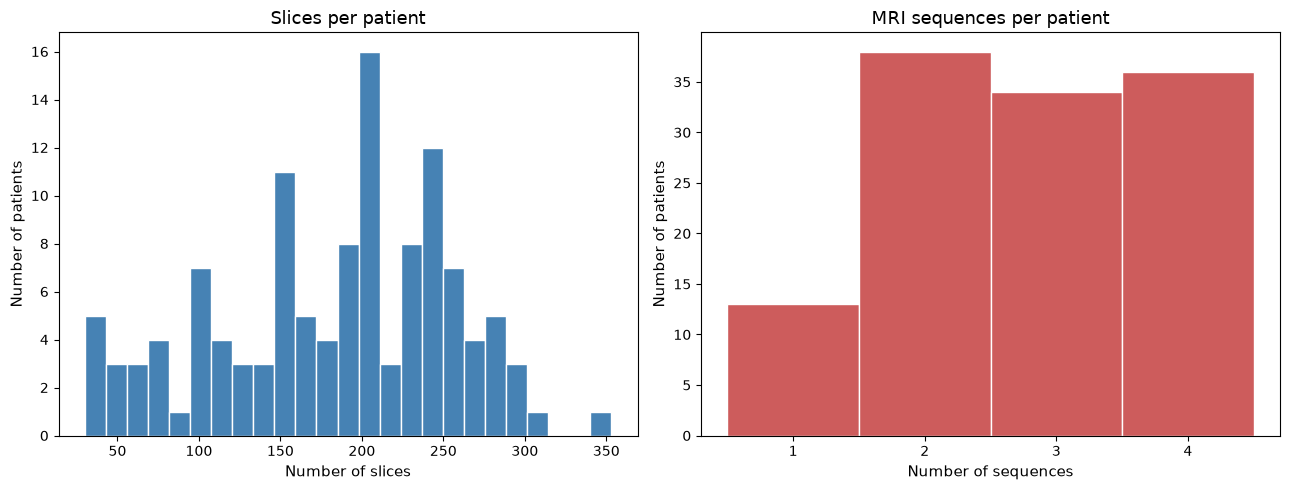

count    121.0
mean     183.3
std       72.5
min       30.0
25%      140.0
50%      196.0
75%      241.0
max      353.0


In [14]:
slices_per_patient = df.groupby("patient_id")["filename"].count()
seq_per_patient = df.groupby("patient_id")["sequence"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(slices_per_patient, bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("Slices per patient")
axes[0].set_xlabel("Number of slices")
axes[0].set_ylabel("Number of patients")

axes[1].hist(seq_per_patient, bins=np.arange(0.5, 5.5, 1), color="indianred", edgecolor="white")
axes[1].set_xticks(range(1, 5))
axes[1].set_title("MRI sequences per patient")
axes[1].set_xlabel("Number of sequences")
axes[1].set_ylabel("Number of patients")

plt.tight_layout()
plt.show()

print(slices_per_patient.describe().round(1).to_string())

## 5. Sample Slice Visualization

One preprocessed slice per sequence (224 × 224, normalized intensities in `[0,1]`).

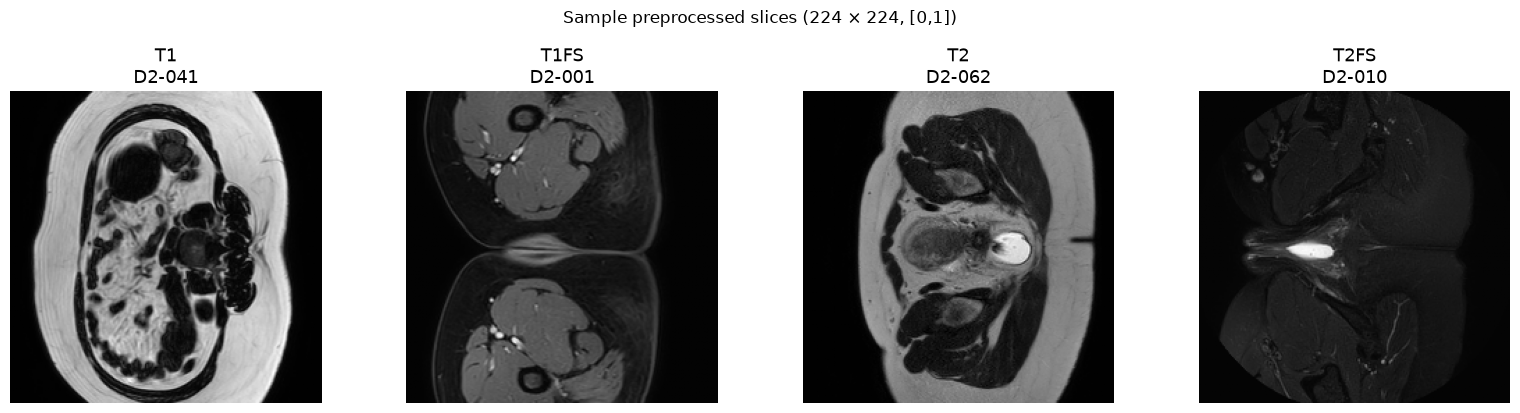

In [16]:
selected = df.groupby("sequence").sample(1, random_state=42)

fig, axes = plt.subplots(1, len(selected), figsize=(4 * len(selected), 4))
for ax, (_, row) in zip(np.atleast_1d(axes), selected.iterrows()):
    arr = np.load(PROCESSED_DIR / Path(row["filename"]))
    ax.imshow(arr, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{row['sequence']}\n{row['patient_id']}")
    ax.axis("off")

plt.suptitle("Sample preprocessed slices (224 × 224, [0,1])", y=1.02)
plt.tight_layout()
plt.show()

## 6. Intensity Distribution

Confirms min-max normalization is correctly scaled to `[0,1]` across all sequences.

T1: min=0.0000,  max=1.0000
T1FS: min=0.0000,  max=1.0000
T2: min=0.0000,  max=1.0000
T2FS: min=0.0000,  max=1.0000


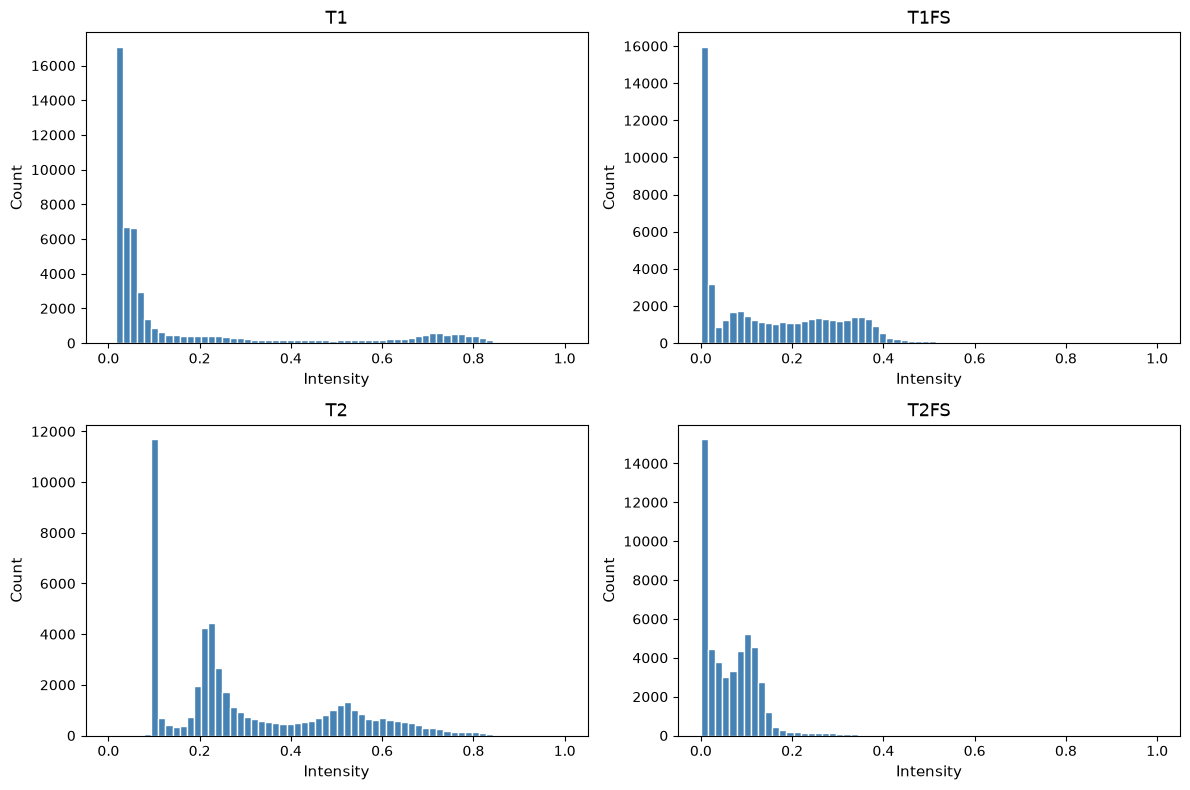

In [17]:
sample_rows = df.groupby("sequence").sample(1, random_state=7)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    arr = np.load(PROCESSED_DIR / Path(row["filename"]))
    ax.hist(arr.ravel(), bins=64, color="steelblue", edgecolor="white")
    ax.set_title(f"{row['sequence']}")
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Count")
    print(f"{row['sequence']}: min={arr.min():.4f},  max={arr.max():.4f}")

plt.tight_layout()
plt.show()

## 7. Slice-Position Montage (raw volume)

Renders every axial slice of one raw T2 volume before preprocessing, to show the anatomical
coverage each patient contributes.

Selected file: D2-054_T2.nii.gz
Volume shape: (384, 384, 34)


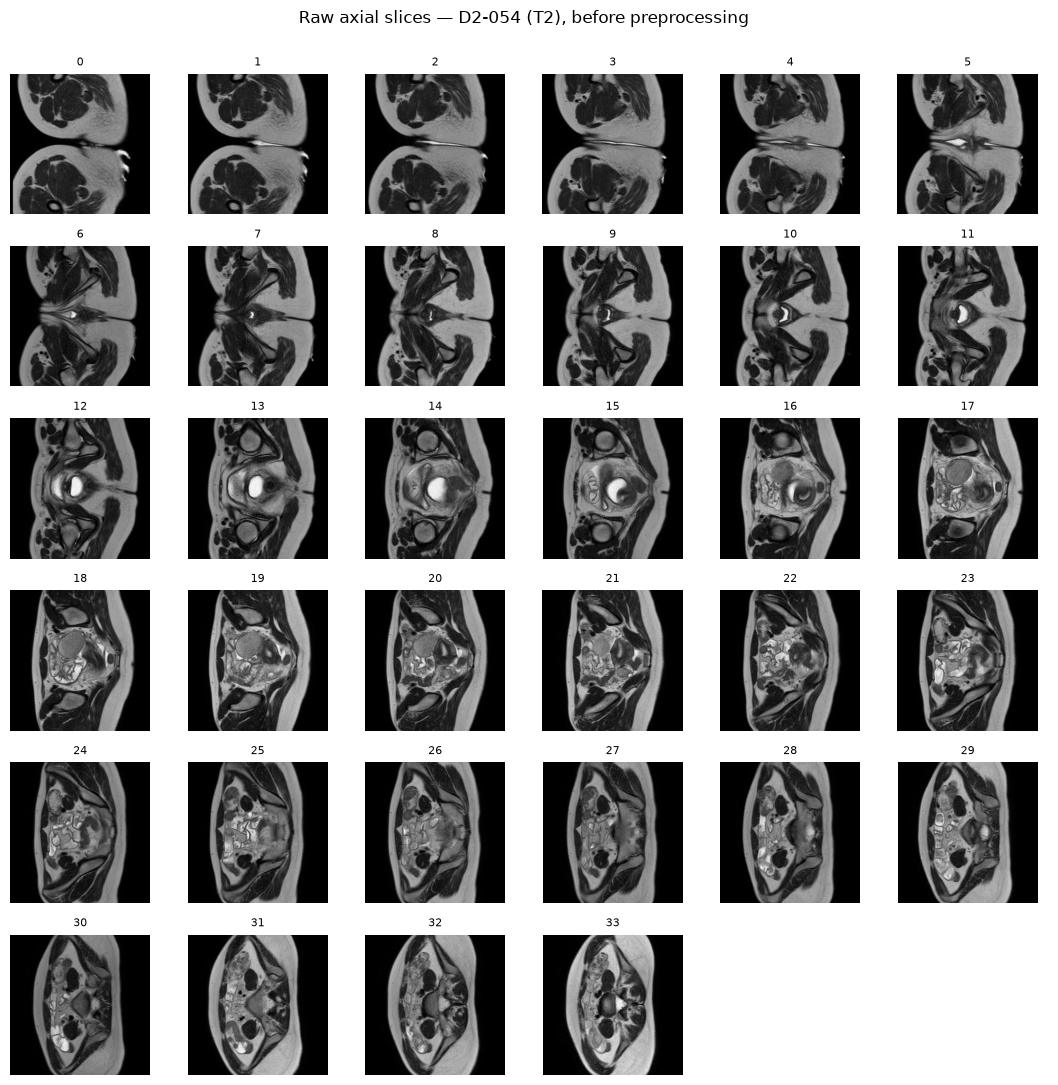

In [18]:
from src.preprocessing.nifti import extract_axial_slices, load_nifti
from src.data.dataset import discover_patients

raw_dir = REPO_ROOT / config["data"]["raw_dir"]
patients = discover_patients(raw_dir, config["preprocessing"]["sequences"])

pid = "D2-054"
t2_file = next(f for f in patients[pid] if "_T2." in f.name)
print("Selected file:", t2_file.name)

volume = load_nifti(t2_file)
print("Volume shape:", volume.shape)

slices = extract_axial_slices(volume)
n = len(slices)
cols = 6
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(slices[i], cmap="gray")
        ax.set_title(str(i), fontsize=8)
    ax.axis("off")

plt.suptitle(f"Raw axial slices — {pid} (T2), before preprocessing", y=1.0)
plt.tight_layout()
plt.show()

## 8. Preprocessing Verification

Random spot-checks that every saved slice matches the expected contract:
shape `(224, 224)`, dtype `float32`, values within `[0, 1]`.

In [19]:
rng = np.random.default_rng(42)
checks = df.sample(25, random_state=42)

shapes_ok = dtype_ok = range_ok = True
missing = 0

expected_shape = tuple(config["preprocessing"]["image_size"])

for _, row in checks.iterrows():
    f = PROCESSED_DIR / Path(row["filename"])
    if not f.exists():
        missing += 1
        continue
    arr = np.load(f)
    shapes_ok &= arr.shape == expected_shape
    dtype_ok &= arr.dtype == np.float32
    range_ok &= bool(arr.min() >= 0.0 and arr.max() <= 1.0)

print("Sample size           :", len(checks))
print("Files missing         :", missing)
print("Shape == 224x224      :", shapes_ok)
print("dtype == float32      :", dtype_ok)
print("Values within [0, 1]  :", range_ok)

Sample size           : 25
Files missing         : 0
Shape == 224x224      : True
dtype == float32      : True
Values within [0, 1]  : True


## 9. Data Quality Notes

Anomalies discovered during EDA and data audit:

- **Missing patients:** `D2-030` through `D2-037` are absent from the local copy
  (`D2_TCPW/`), so patient ranges are not contiguous.
- **Undocumented files:** `D2-014_pat.nii.gz`, `D2-068_pat.nii.gz`, `D2-069_pat.nii.gz`
  use an undefined `_pat` suffix — not used as sequence inputs.
- **Filename typo:** `D1-026_ut_re3.nii.gz` (`re3` instead of `r3`) — label file, excluded
  from the classification inputs anyway.
- **D1 vs D2 conventions:** D1 has three raters (`_r1/_r2/_r3`) and only ut/ov/em labels;
  D2 is single-rater and adds `cy`/`cds`. Only the MRI sequence files (`T1/T1FS/T2/T2FS`)
  enter the classification pipeline; labels are reserved for later Grad-CAM validation.
- **Class imbalance pending:** all current slices are endometriosis-positive until the
  healthy pelvis dataset is added; class weighting is already planned in the methodology.